# StealthVision — Pipeline ML: Feature Extractor & Clasificadores de Escenario

**Proyecto:** StealthVision — Sistema de detección inteligente integrado con Unreal Engine  
**Módulo:** Clasificación de escenarios de riesgo mediante Machine Learning  

---

## Arquitectura del sistema

```
Unreal Engine (frame)
       ↓
  RT-DETR (Transformer)          ← IA de detección de objetos
       ↓  bboxes + clases
  FeatureExtractor                ← convierte detecciones en vector numérico
       ↓  vector float32
  GradientBoostingClassifier      ← IA de clasificación de escenarios
       ↓  scenario + probabilidades
  Motor de respuesta              ← genera título, consejo, nivel de riesgo
       ↓
  JSON → Unreal Engine
```

Este notebook demuestra las capas 2 y 3 del pipeline: **extracción de features** y **clasificación ML**.

---
## 1. Imports y configuración

In [1]:
import sys, os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# Aseguramos que el directorio raíz del proyecto esté en el path
PROJECT_ROOT = os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from feature_extractor import (
    extract_traffic_features,
    extract_security_features,
    TRAFFIC_FEATURE_NAMES,
    SECURITY_FEATURE_NAMES,
    CLASS_PERSON, CLASS_BICYCLE, CLASS_CAR, CLASS_MOTORCYCLE,
    CLASS_BUS, CLASS_TRUCK, CLASS_KNIFE, CLASS_SCISSORS,
    CLASS_BACKPACK,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

print("Imports OK")
print(f"  Features de tráfico  : {len(TRAFFIC_FEATURE_NAMES)}")
print(f"  Features de seguridad: {len(SECURITY_FEATURE_NAMES)}")

Imports OK
  Features de tráfico  : 18
  Features de seguridad: 15


---
## 2. Feature Extractor — ¿Qué son las features?

El `FeatureExtractor` toma la lista cruda de detecciones del modelo RT-DETR  
y las transforma en un **vector numérico compacto** que el clasificador puede procesar.

Cada elemento del vector captura una característica geométrica o contextual  
calculada a partir de las posiciones y clases de los objetos detectados.

### Ejemplo de detecciones crudas (salida de RT-DETR)

In [2]:
# Simulamos la salida de RT-DETR para un escenario: persona muy cerca de un auto
detecciones_ejemplo = [
    {"class_id": CLASS_PERSON, "class_name": "person",     "confidence": 0.94, "bbox": [290, 180, 350, 420]},
    {"class_id": CLASS_CAR,    "class_name": "car",        "confidence": 0.89, "bbox": [300, 200, 580, 400]},
    {"class_id": CLASS_PERSON, "class_name": "person",     "confidence": 0.81, "bbox": [ 50,  80, 110, 320]},
]

print("Detecciones crudas (formato RT-DETR):")
print("-" * 55)
for d in detecciones_ejemplo:
    print(f"  clase: {d['class_name']:10s}  conf: {d['confidence']:.2f}  bbox: {d['bbox']}")

print(f"\nTotal objetos detectados: {len(detecciones_ejemplo)}")

Detecciones crudas (formato RT-DETR):
-------------------------------------------------------
  clase: person      conf: 0.94  bbox: [290, 180, 350, 420]
  clase: car         conf: 0.89  bbox: [300, 200, 580, 400]
  clase: person      conf: 0.81  bbox: [50, 80, 110, 320]

Total objetos detectados: 3


### Transformación: detecciones → vector de features

In [3]:
IMAGE_SHAPE = (600, 600, 3)

# Extraemos el vector de features
vector = extract_traffic_features(detecciones_ejemplo, IMAGE_SHAPE)

print("Vector de features extraido (18 dimensiones):")
print("=" * 52)
for i, (nombre, valor) in enumerate(zip(TRAFFIC_FEATURE_NAMES, vector)):
    barra = "#" * int(valor * 20) if valor <= 1.0 else "#" * 20
    print(f"  [{i:2d}] {nombre:35s} = {valor:6.3f}  |{barra}")

print(f"\nForma del vector: {vector.shape}  |  Dtype: {vector.dtype}")

Vector de features extraido (18 dimensiones):
  [ 0] n_persons                           =  2.000  |####################
  [ 1] n_vehicles                          =  1.000  |####################
  [ 2] n_bicycles                          =  0.000  |
  [ 3] n_large_vehicles                    =  0.000  |
  [ 4] n_traffic_lights                    =  0.000  |
  [ 5] n_stop_signs                        =  0.000  |
  [ 6] min_person_vehicle_dist             =  0.200  |####
  [ 7] max_person_danger_zone_iou          =  0.117  |##
  [ 8] person_vehicle_direct_overlap       =  1.000  |####################
  [ 9] min_bicycle_largeveh_dist           =  1.000  |####################
  [10] brightness_norm                     =  0.502  |##########
  [11] is_dark                             =  0.000  |
  [12] person_vehicle_ratio                =  1.000  |####################
  [13] total_detections                    =  3.000  |####################
  [14] both_person_and_vehicle             =  1.

### Visualización del vector de features

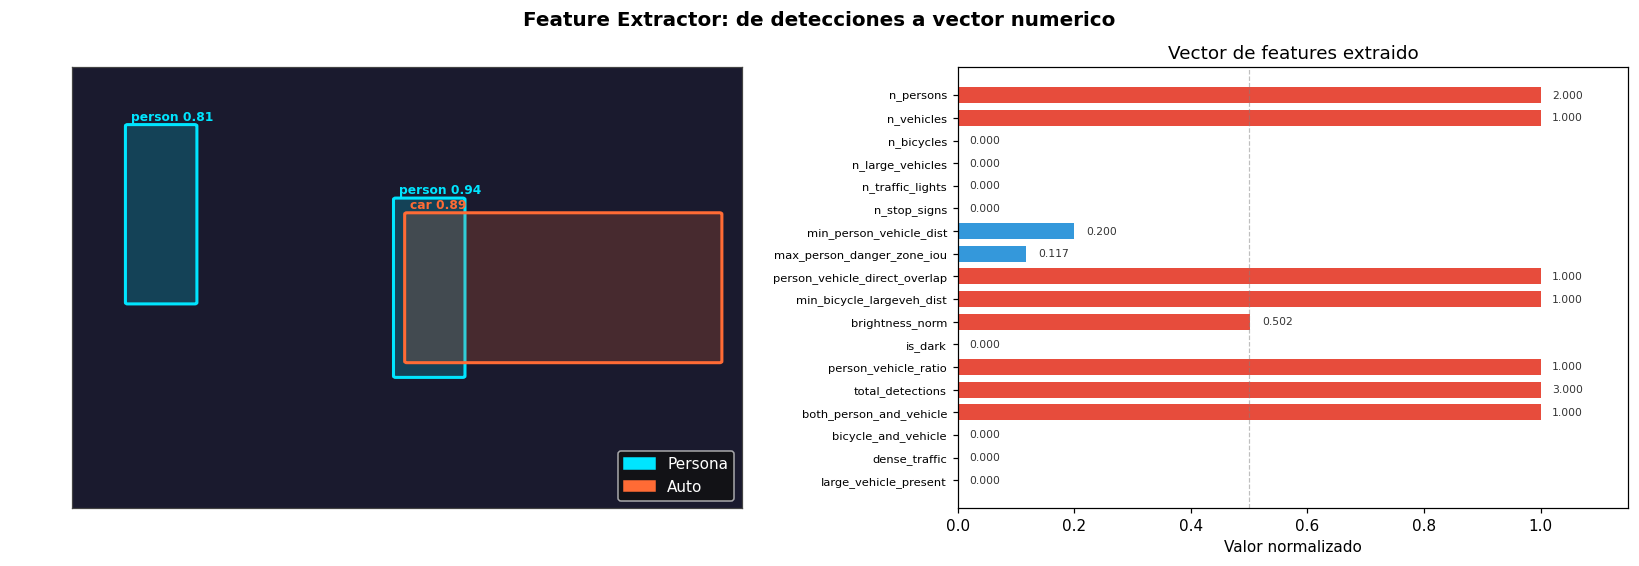

Grafica guardada en output/feature_extractor_demo.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Izquierda: escena simulada ---
ax1.set_xlim(0, 600); ax1.set_ylim(0, 600); ax1.invert_yaxis()
ax1.set_facecolor("#1a1a2e")
ax1.set_title("Escena simulada (salida RT-DETR)", fontsize=12, color="white", pad=10)
ax1.tick_params(colors="white"); ax1.set_xlabel("x (px)", color="white"); ax1.set_ylabel("y (px)", color="white")
for spine in ax1.spines.values(): spine.set_edgecolor("#444")

colores = {"person": ("#00e5ff", "Persona"), "car": ("#ff6b35", "Auto")}
for d in detecciones_ejemplo:
    x1, y1, x2, y2 = d["bbox"]
    cl = d["class_name"]
    color, label = colores.get(cl, ("#aaa", cl))
    rect = mpatches.FancyBboxPatch((x1, y1), x2-x1, y2-y1,
                                    boxstyle="round,pad=2", linewidth=2,
                                    edgecolor=color, facecolor=color+"33")
    ax1.add_patch(rect)
    ax1.text(x1+3, y1-8, f"{cl} {d['confidence']:.2f}",
             color=color, fontsize=8, fontweight="bold")

legend_handles = [mpatches.Patch(color=c, label=l) for c, l in colores.values()]
ax1.legend(handles=legend_handles, loc="lower right", facecolor="#111", labelcolor="white")

# --- Derecha: vector de features ---
nombres_cortos = [n.replace("_", "\n") for n in TRAFFIC_FEATURE_NAMES]
valores_norm   = np.clip(vector, 0, 1)
colores_barra  = ["#e74c3c" if v > 0.5 else "#3498db" for v in valores_norm]

bars = ax2.barh(range(len(vector)), valores_norm, color=colores_barra, edgecolor="none", height=0.7)
ax2.set_yticks(range(len(TRAFFIC_FEATURE_NAMES)))
ax2.set_yticklabels(TRAFFIC_FEATURE_NAMES, fontsize=7.5)
ax2.set_xlim(0, 1.15)
ax2.set_xlabel("Valor normalizado")
ax2.set_title("Vector de features extraido", fontsize=12)
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
for i, (bar, val) in enumerate(zip(bars, vector)):
    ax2.text(valores_norm[i] + 0.02, i, f"{val:.3f}", va="center", fontsize=7, color="#333")
ax2.invert_yaxis()

plt.tight_layout()
plt.suptitle("Feature Extractor: de detecciones a vector numerico", y=1.02,
             fontsize=13, fontweight="bold")
plt.savefig("output/feature_extractor_demo.png", bbox_inches="tight", dpi=130)
plt.show()
print("Grafica guardada en output/feature_extractor_demo.png")

---
## 3. Carga de los modelos entrenados

Los clasificadores fueron entrenados con **56,000 escenarios sintéticos** para tráfico  
y **49,000** para seguridad, generados con posicionamiento parametrizado y etiquetados  
automáticamente por el motor de reglas experto.

In [5]:
with open("models/traffic_clf.pkl",  "rb") as f: clf_traffic   = pickle.load(f)
with open("models/security_clf.pkl", "rb") as f: clf_security  = pickle.load(f)

print("Modelos cargados:")
print(f"  TrafficClassifier  — clases: {list(clf_traffic.classes_)}")
print(f"  SecurityClassifier — clases: {list(clf_security.classes_)}")
print()

# Tamaño de los modelos en disco
for path, nombre in [("models/traffic_clf.pkl","TrafficClassifier"),
                     ("models/security_clf.pkl","SecurityClassifier")]:
    size_mb = os.path.getsize(path) / 1024 / 1024
    print(f"  {nombre:20s} {size_mb:.1f} MB en disco")

Modelos cargados:
  TrafficClassifier  — clases: [np.str_('atropello_inminente'), np.str_('ciclista_entre_vehiculos'), np.str_('ciclista_sin_proteccion'), np.str_('peaton_en_calzada'), np.str_('persona_cerca_vehiculo'), np.str_('trafico_denso_peaton'), np.str_('zona_oscura'), np.str_('zona_oscura_con_trafico'), np.str_('zona_segura')]
  SecurityClassifier — clases: [np.str_('arma_detectada'), np.str_('confrontacion'), np.str_('encercamiento'), np.str_('grupo_sospechoso'), np.str_('merodeo'), np.str_('situacion_normal'), np.str_('zona_oscura_persona')]

  TrafficClassifier    7.2 MB en disco
  SecurityClassifier   3.4 MB en disco


---
## 4. Feature Importances — ¿Qué le importa al modelo?

Una de las ventajas del GradientBoosting es que podemos ver **qué features influyeron más**  
en las decisiones del clasificador durante el entrenamiento.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13660\257052038.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(color_base, len(vals))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13660\257052038.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(color_base, len(vals))


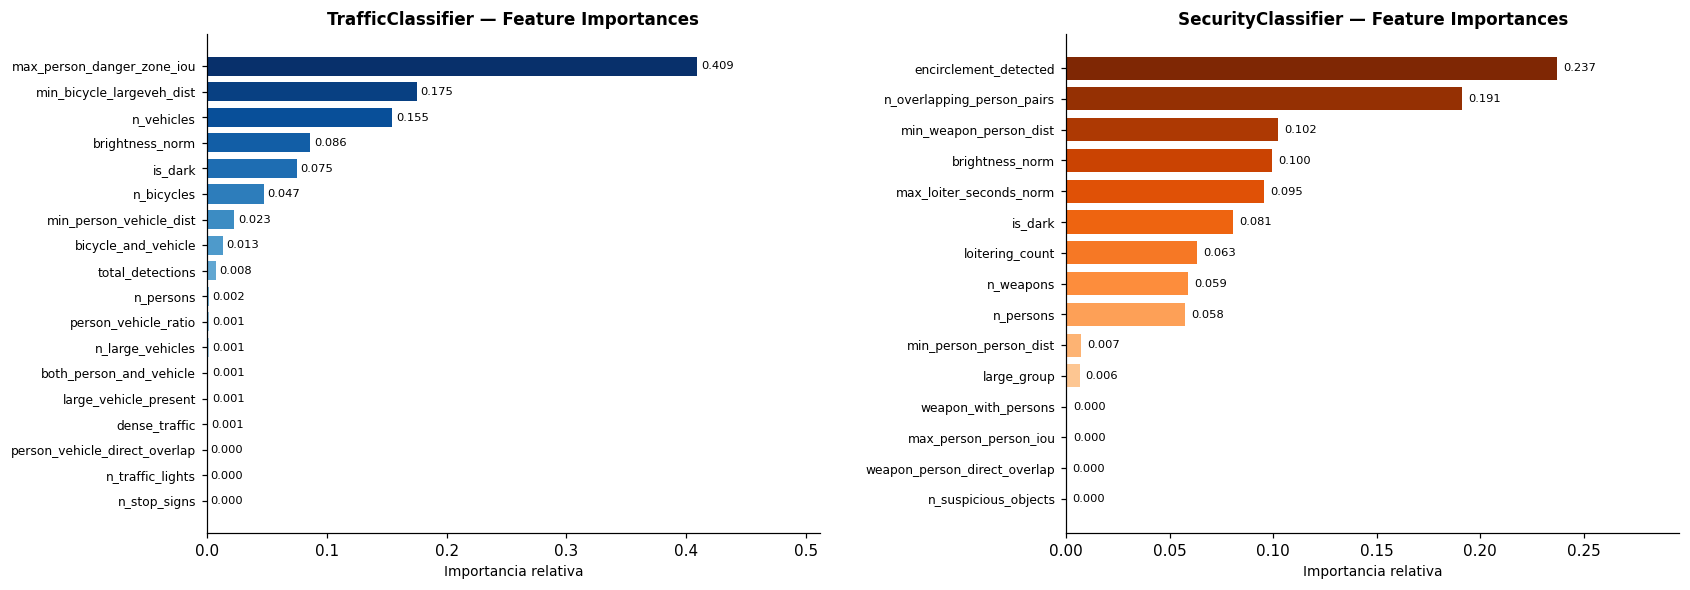

Grafica guardada en output/feature_importances.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

def plot_importances(ax, clf, feature_names, titulo, color_base):
    imp  = clf.feature_importances_
    idx  = np.argsort(imp)
    vals = imp[idx]
    noms = [feature_names[i] for i in idx]
    cmap = plt.cm.get_cmap(color_base, len(vals))
    colors = [cmap(i / len(vals)) for i in range(len(vals))]
    bars = ax.barh(range(len(vals)), vals, color=colors, edgecolor="none", height=0.75)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(noms, fontsize=8)
    ax.set_xlabel("Importancia relativa", fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    for bar, val in zip(bars, vals):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=7.5)
    ax.set_xlim(0, max(vals) * 1.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_importances(ax1, clf_traffic,  TRAFFIC_FEATURE_NAMES,
                 "TrafficClassifier — Feature Importances", "Blues")
plot_importances(ax2, clf_security, SECURITY_FEATURE_NAMES,
                 "SecurityClassifier — Feature Importances", "Oranges")

plt.tight_layout(pad=3)
plt.savefig("output/feature_importances.png", bbox_inches="tight", dpi=130)
plt.show()
print("Grafica guardada en output/feature_importances.png")

---
## 5. Demo de predicciones — TrafficClassifier

Probamos el clasificador con 6 escenarios distintos y visualizamos  
la **distribución de probabilidades** por clase en cada caso.

In [7]:
def det(class_id, bbox, conf=0.90):
    nombres = {0:"person",1:"bicycle",2:"car",3:"motorcycle",5:"bus",
               7:"truck",9:"traffic light",11:"stop sign",24:"backpack",43:"knife",76:"scissors"}
    return {"class_id": class_id, "class_name": nombres.get(class_id,str(class_id)),
            "confidence": conf, "bbox": bbox}

IMG = (600, 600, 3)
fake_bright = np.full((32,32,3), 180, dtype=np.uint8)
fake_dark   = np.full((32,32,3),  40, dtype=np.uint8)

ESCENARIOS_TRAFICO = {
    "Zona segura\n(sin vehiculos)": (
        [det(CLASS_PERSON, [100,100,160,350]),
         det(CLASS_PERSON, [400,200,460,450])], fake_bright
    ),
    "Atropello inminente\n(overlap persona-auto)": (
        [det(CLASS_PERSON, [295,190,355,410]),
         det(CLASS_CAR,    [300,200,580,400])], fake_bright
    ),
    "Persona cerca\ndel vehiculo": (
        [det(CLASS_PERSON, [200,150,260,400]),
         det(CLASS_CAR,    [310,200,560,390])], fake_bright
    ),
    "Ciclista entre\nvehiculos grandes": (
        [det(CLASS_BICYCLE,[260,200,330,380]),
         det(CLASS_BUS,    [290,180,580,400]),
         det(CLASS_TRUCK,  [ 10,190,250,390])], fake_bright
    ),
    "Zona oscura\n(sin trafico)": (
        [det(CLASS_PERSON, [200,100,260,350])], fake_dark
    ),
    "Zona oscura\n+ vehiculos": (
        [det(CLASS_PERSON, [200,100,260,350]),
         det(CLASS_CAR,    [300,200,560,400])], fake_dark
    ),
}

print(f"{'Escenario':<35} {'Prediccion ML':<28} {'Confianza':>10}")
print("-" * 75)
resultados_t = []
for nombre, (dets, img) in ESCENARIOS_TRAFICO.items():
    feats = extract_traffic_features(dets, IMG, img)
    pred  = clf_traffic.predict(feats.reshape(1,-1))[0]
    probs = clf_traffic.predict_proba(feats.reshape(1,-1))[0]
    conf  = probs.max()
    resultados_t.append((nombre, pred, probs, conf))
    etiqueta_corta = nombre.replace("\n"," ")
    print(f"  {etiqueta_corta:<33} {pred:<28} {conf*100:>8.1f}%")

Escenario                           Prediccion ML                 Confianza
---------------------------------------------------------------------------
  Zona segura (sin vehiculos)       zona_segura                     100.0%
  Atropello inminente (overlap persona-auto) atropello_inminente             100.0%
  Persona cerca del vehiculo        atropello_inminente             100.0%
  Ciclista entre vehiculos grandes  ciclista_entre_vehiculos        100.0%
  Zona oscura (sin trafico)         zona_oscura                     100.0%
  Zona oscura + vehiculos           atropello_inminente             100.0%


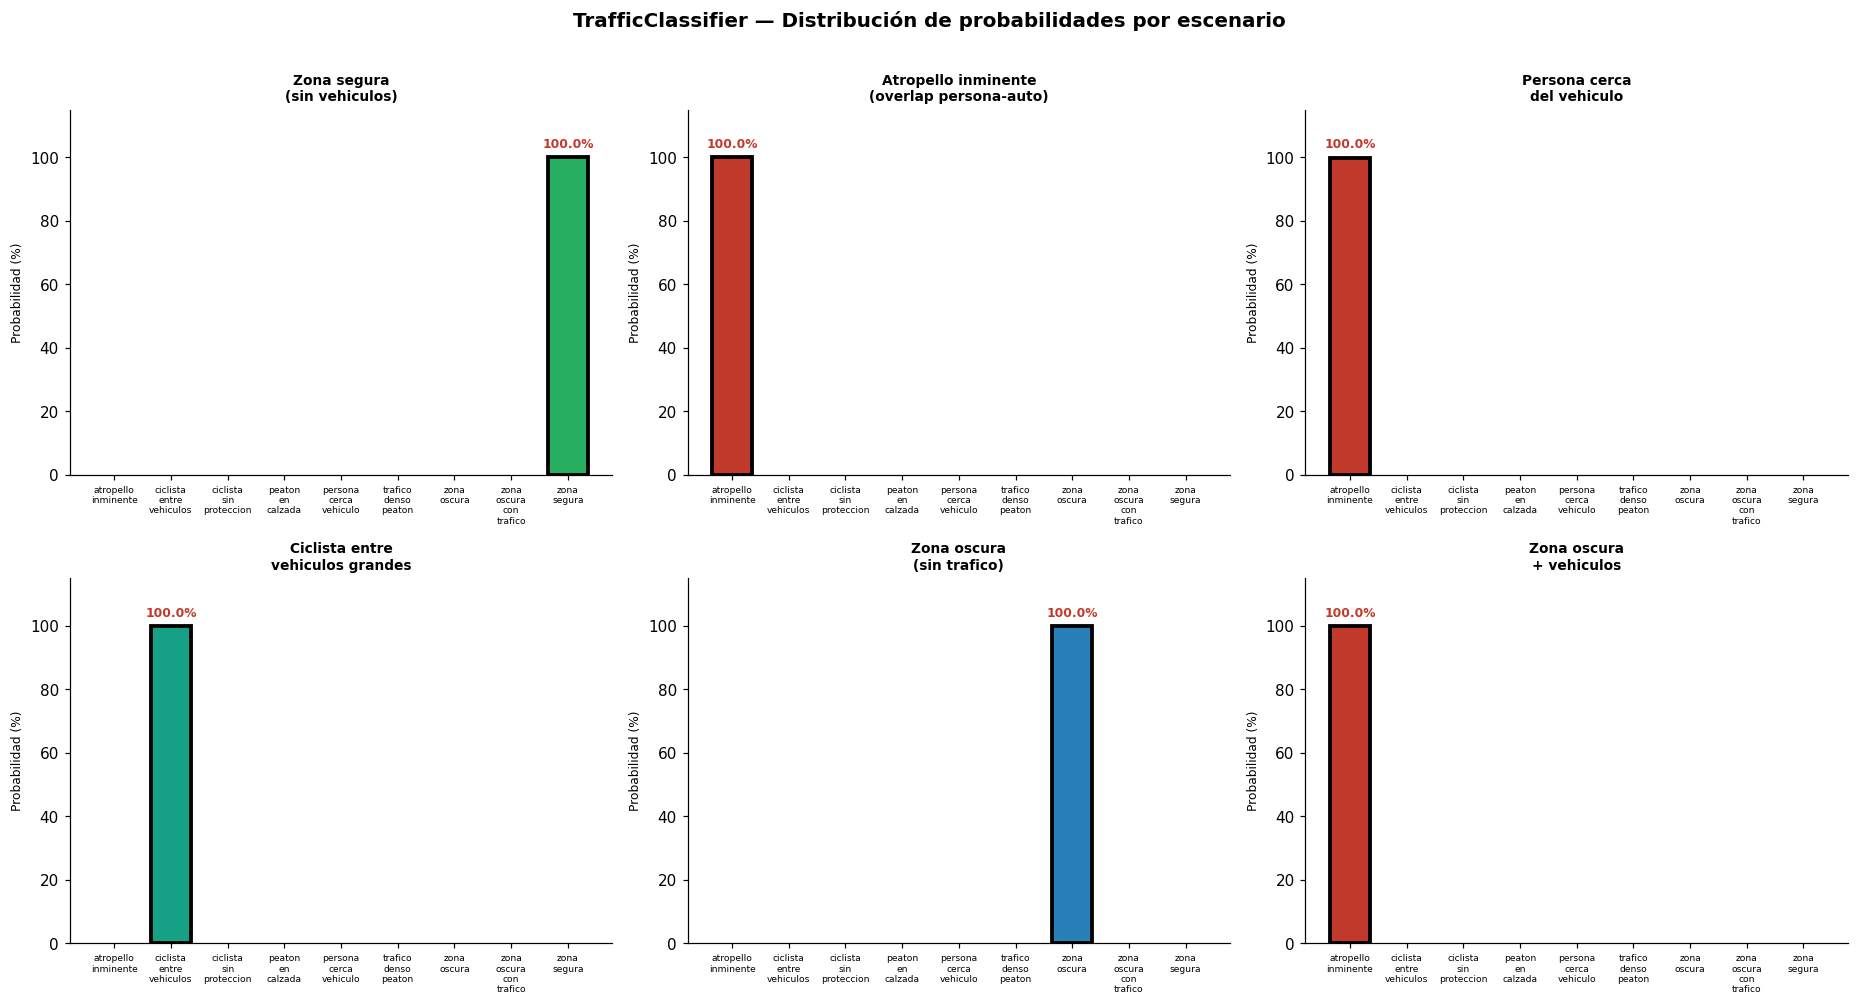

Grafica guardada en output/traffic_predictions.png


In [8]:
# Gráfica de probabilidades por escenario
clases_t = list(clf_traffic.classes_)
COLORES_RIESGO = {
    "zona_segura":             "#27ae60",
    "zona_oscura":             "#2980b9",
    "zona_oscura_con_trafico": "#c0392b",
    "peaton_en_calzada":       "#f39c12",
    "trafico_denso_peaton":    "#e67e22",
    "ciclista_sin_proteccion": "#8e44ad",
    "ciclista_entre_vehiculos":"#16a085",
    "persona_cerca_vehiculo":  "#d35400",
    "atropello_inminente":     "#c0392b",
}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for ax, (nombre, pred, probs, conf) in zip(axes, resultados_t):
    colores = [COLORES_RIESGO.get(c, "#95a5a6") for c in clases_t]
    bars = ax.bar(range(len(clases_t)), probs * 100, color=colores, edgecolor="none", width=0.7)
    pred_idx = list(clases_t).index(pred)
    bars[pred_idx].set_edgecolor("black")
    bars[pred_idx].set_linewidth(2.5)
    ax.set_xticks(range(len(clases_t)))
    ax.set_xticklabels([c.replace("_","\n") for c in clases_t], fontsize=6, rotation=0)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Probabilidad (%)", fontsize=8)
    ax.set_title(nombre, fontsize=9, fontweight="bold")
    ax.text(pred_idx, probs[pred_idx]*100 + 3, f"{conf*100:.1f}%",
            ha="center", fontsize=8, fontweight="bold", color="#c0392b")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("TrafficClassifier — Distribución de probabilidades por escenario",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("output/traffic_predictions.png", bbox_inches="tight", dpi=130)
plt.show()
print("Grafica guardada en output/traffic_predictions.png")

---
## 6. Demo de predicciones — SecurityClassifier

In [9]:
ESCENARIOS_SEG = {
    "Situacion normal\n(2 personas)": {
        "dets": [det(CLASS_PERSON, [100,100,160,380]),
                 det(CLASS_PERSON, [400,150,460,420])],
        "img": fake_bright, "loiter_count": 0, "loiter_secs": 0.0,
    },
    "Arma detectada\n(cuchillo cerca)": {
        "dets": [det(CLASS_PERSON, [200,100,260,380]),
                 det(CLASS_KNIFE,  [240,150,280,230])],
        "img": fake_bright, "loiter_count": 0, "loiter_secs": 0.0,
    },
    "Confrontacion\n(personas en contacto)": {
        "dets": [det(CLASS_PERSON, [270,150,330,400]),
                 det(CLASS_PERSON, [310,150,370,400])],
        "img": fake_bright, "loiter_count": 0, "loiter_secs": 0.0,
    },
    "Encercamiento\n(rodeada por 4)": {
        "dets": [det(CLASS_PERSON, [290,270,350,430]),   # target
                 det(CLASS_PERSON, [380,270,440,430]),   # E
                 det(CLASS_PERSON, [200,270,260,430]),   # W
                 det(CLASS_PERSON, [290,360,350,520]),   # S
                 det(CLASS_PERSON, [290,180,350,340])],  # N
        "img": fake_bright, "loiter_count": 0, "loiter_secs": 0.0,
    },
    "Merodeo\n(persona inmovil 12s)": {
        "dets": [det(CLASS_PERSON, [200,100,260,380])],
        "img": fake_bright, "loiter_count": 1, "loiter_secs": 12.0,
    },
    "Zona oscura\ncon personas": {
        "dets": [det(CLASS_PERSON, [200,100,260,380]),
                 det(CLASS_PERSON, [380,200,440,450])],
        "img": fake_dark, "loiter_count": 0, "loiter_secs": 0.0,
    },
}

print(f"{'Escenario':<35} {'Prediccion ML':<22} {'Confianza':>10}")
print("-" * 70)
resultados_s = []
for nombre, cfg in ESCENARIOS_SEG.items():
    feats = extract_security_features(cfg["dets"], IMG, cfg["img"])
    feats[9]  = float(cfg["loiter_count"])
    feats[10] = min(cfg["loiter_secs"] / 10.0, 1.0)
    pred  = clf_security.predict(feats.reshape(1,-1))[0]
    probs = clf_security.predict_proba(feats.reshape(1,-1))[0]
    conf  = probs.max()
    resultados_s.append((nombre, pred, probs, conf))
    etiqueta = nombre.replace("\n"," ")
    print(f"  {etiqueta:<33} {pred:<22} {conf*100:>8.1f}%")

Escenario                           Prediccion ML           Confianza
----------------------------------------------------------------------
  Situacion normal (2 personas)     situacion_normal          100.0%
  Arma detectada (cuchillo cerca)   arma_detectada            100.0%
  Confrontacion (personas en contacto) confrontacion             100.0%
  Encercamiento (rodeada por 4)     encercamiento             100.0%
  Merodeo (persona inmovil 12s)     merodeo                   100.0%
  Zona oscura con personas          zona_oscura_persona       100.0%


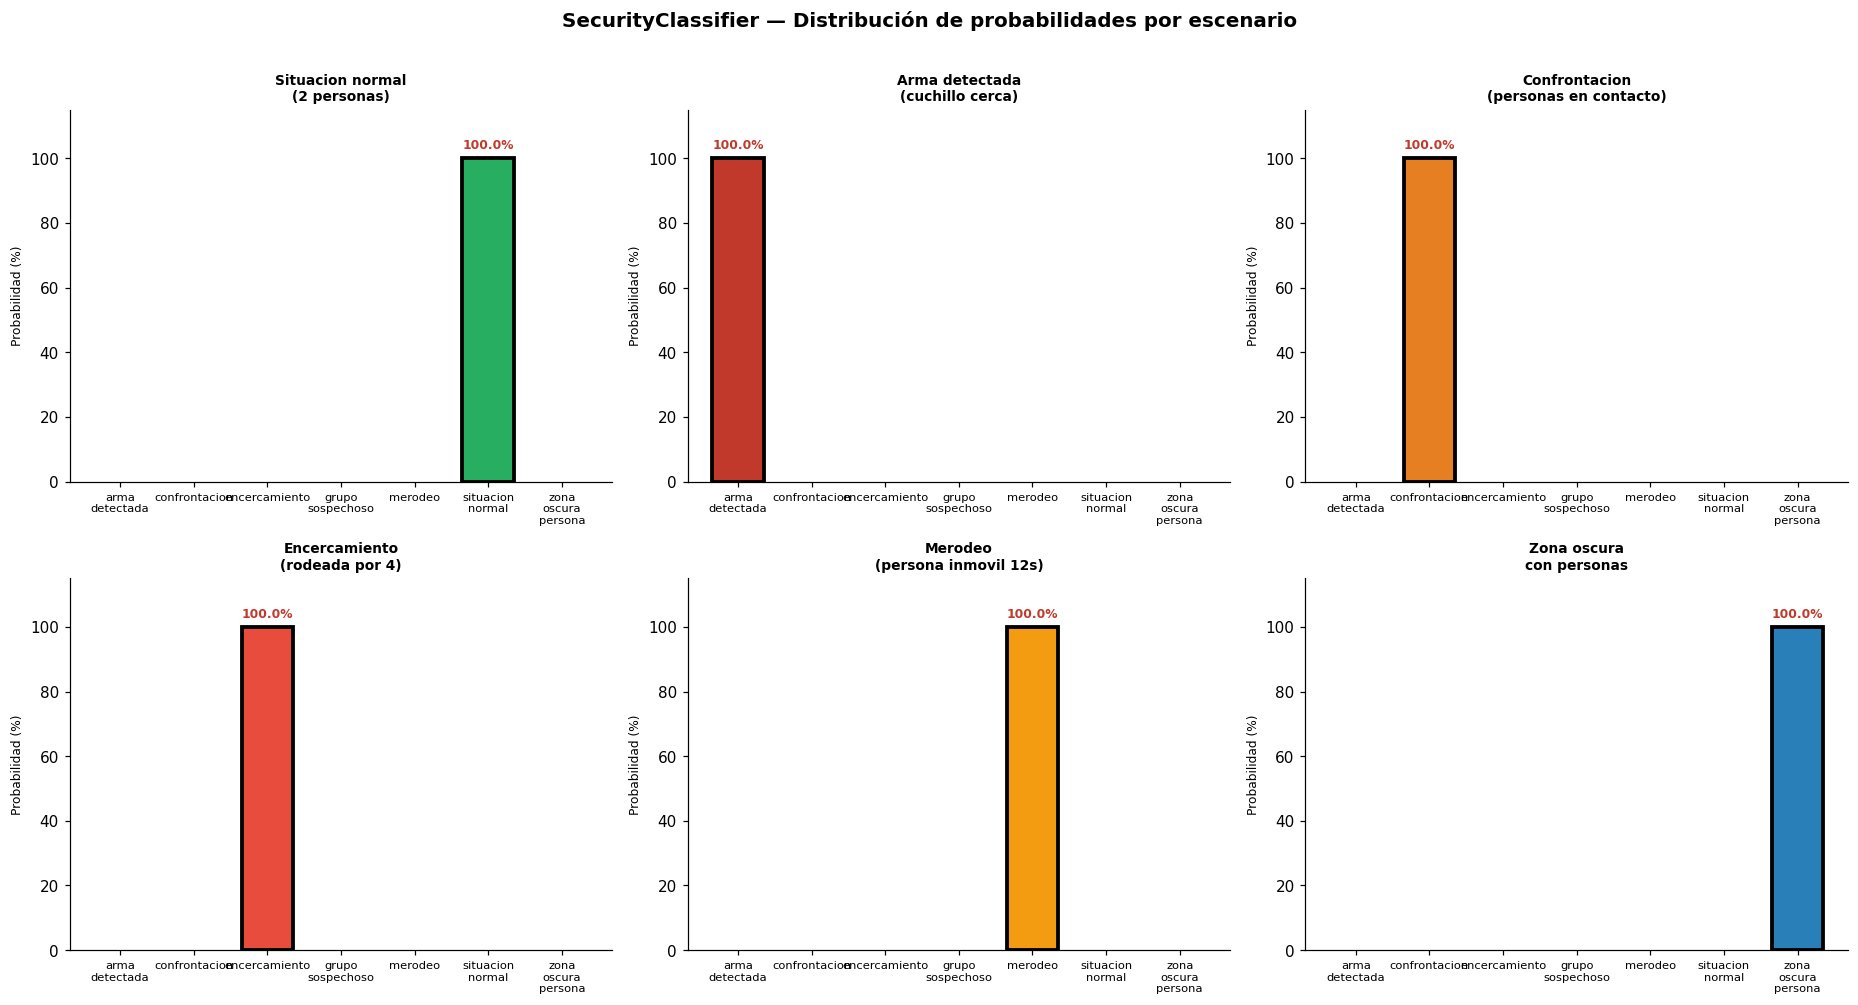

Grafica guardada en output/security_predictions.png


In [10]:
clases_s = list(clf_security.classes_)
COLORES_SEG = {
    "situacion_normal":    "#27ae60",
    "zona_oscura_persona": "#2980b9",
    "grupo_sospechoso":    "#8e44ad",
    "merodeo":             "#f39c12",
    "confrontacion":       "#e67e22",
    "encercamiento":       "#e74c3c",
    "arma_detectada":      "#c0392b",
}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for ax, (nombre, pred, probs, conf) in zip(axes, resultados_s):
    colores = [COLORES_SEG.get(c, "#95a5a6") for c in clases_s]
    bars = ax.bar(range(len(clases_s)), probs * 100, color=colores, edgecolor="none", width=0.7)
    pred_idx = list(clases_s).index(pred)
    bars[pred_idx].set_edgecolor("black")
    bars[pred_idx].set_linewidth(2.5)
    ax.set_xticks(range(len(clases_s)))
    ax.set_xticklabels([c.replace("_","\n") for c in clases_s], fontsize=7.5)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Probabilidad (%)", fontsize=8)
    ax.set_title(nombre, fontsize=9, fontweight="bold")
    ax.text(pred_idx, probs[pred_idx]*100 + 3, f"{conf*100:.1f}%",
            ha="center", fontsize=8, fontweight="bold", color="#c0392b")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("SecurityClassifier — Distribución de probabilidades por escenario",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("output/security_predictions.png", bbox_inches="tight", dpi=130)
plt.show()
print("Grafica guardada en output/security_predictions.png")

---
## 7. Pipeline completo end-to-end

Simulamos el flujo real: desde detecciones crudas hasta respuesta JSON final,  
exactamente como lo recibe Unreal Engine.

In [11]:
import json, time
from traffic_risk_engine import TrafficRiskEngine
from suspicious_behavior_engine import SuspiciousBehaviorEngine

engine_traffic   = TrafficRiskEngine()
engine_security  = SuspiciousBehaviorEngine()

print("=" * 60)
print("PIPELINE TRAFICO — escenario: atropello inminente")
print("=" * 60)

frame_trafico = [
    det(CLASS_PERSON, [295,190,355,410], conf=0.94),
    det(CLASS_CAR,    [300,200,580,400], conf=0.89),
    det(CLASS_PERSON, [50,  80, 110,320], conf=0.77),
]

t0     = time.time()
result = engine_traffic.analyze(frame_trafico, (600,600,3), image=fake_bright)
dt     = (time.time() - t0) * 1000

print(json.dumps({
    "risk_level":     result["risk_level"],
    "scenario_key":   result["scenario_key"],
    "titulo":         result["titulo"],
    "consejo_rapido": result["consejo_rapido"],
    "scenario_probs": result.get("scenario_probs", {}),
    "inference_ms":   round(dt, 3),
}, indent=2, ensure_ascii=False))

TrafficRiskEngine: modelo ML cargado (models\traffic_clf.pkl)
SuspiciousBehaviorEngine: modelo ML cargado (models\security_clf.pkl)
PIPELINE TRAFICO — escenario: atropello inminente
{
  "risk_level": "CRITICAL",
  "scenario_key": "atropello_inminente",
  "titulo": "¡PELIGRO! Riesgo de atropello",
  "consejo_rapido": "PARA. Mira a ambos lados. Cruza solo cuando sea seguro.",
  "scenario_probs": {
    "atropello_inminente": 1.0,
    "ciclista_entre_vehiculos": 0.0,
    "ciclista_sin_proteccion": 0.0,
    "peaton_en_calzada": 0.0,
    "persona_cerca_vehiculo": 0.0,
    "trafico_denso_peaton": 0.0,
    "zona_oscura": 0.0,
    "zona_oscura_con_trafico": 0.0,
    "zona_segura": 0.0
  },
  "inference_ms": 5.967
}


In [12]:
print("=" * 60)
print("PIPELINE SEGURIDAD — escenario: arma detectada")
print("=" * 60)

frame_seg = [
    det(CLASS_PERSON, [200,100,260,380], conf=0.91),
    det(CLASS_KNIFE,  [240,150,280,230], conf=0.82),
]

t0      = time.time()
result2 = engine_security.analyze(frame_seg, (600,600,3), image=fake_bright,
                                  timestamp=time.time(), session_id="demo")
dt2     = (time.time() - t0) * 1000

print(json.dumps({
    "risk_level":     result2["risk_level"],
    "scenario_key":   result2["scenario_key"],
    "titulo":         result2["titulo"],
    "accion":         result2["accion"],
    "scenario_probs": result2.get("scenario_probs", {}),
    "tracks":         result2["tracks"],
    "inference_ms":   round(dt2, 3),
}, indent=2, ensure_ascii=False))

PIPELINE SEGURIDAD — escenario: arma detectada
{
  "risk_level": "CRITICAL",
  "scenario_key": "arma_detectada",
  "titulo": "ALERTA: Arma blanca visible",
  "accion": "Activar protocolo de seguridad. Alertar a personal inmediatamente.",
  "scenario_probs": {
    "arma_detectada": 1.0,
    "confrontacion": 0.0,
    "encercamiento": 0.0,
    "grupo_sospechoso": 0.0,
    "merodeo": 0.0,
    "situacion_normal": 0.0,
    "zona_oscura_persona": 0.0
  },
  "tracks": [
    {
      "track_id": 0,
      "loitering": false,
      "age_seconds": 0.0,
      "bbox": [
        200,
        100,
        260,
        380
      ]
    }
  ],
  "inference_ms": 3.261
}


---
## 8. Resumen del pipeline ML

| Componente | Tecnología | Rol |
|---|---|---|
| **RT-DETR** | Vision Transformer (ONNX) | Detecta y localiza objetos en cada frame |
| **FeatureExtractor** | NumPy (geometría) | Convierte bboxes en vector numérico de 15-18 features |
| **GradientBoostingClassifier** | scikit-learn | Clasifica el escenario + devuelve probabilidades |
| **PersonTracker** | IoU-based (NumPy) | Mantiene identidad de personas entre frames (merodeo) |
| **Motor de respuesta** | Diccionario de escenarios | Genera título, consejo y nivel de riesgo |

### Ventajas del clasificador ML sobre reglas hardcodeadas

- Devuelve **probabilidades** por clase — no solo la clase ganadora
- Aprende **combinaciones no lineales** de features (ej: oscuridad + vehículo + persona cerca = CRITICAL con más peso que si fueran independientes)
- **Reentrenable** cuando se dispongan datos reales etiquetados de Unreal Engine
- **Interpretable**: feature importances muestran qué variables más influyen

### Para reentrenar con nuevos datos
```bash
python train_scenario_classifier.py
```
Y reiniciar el servidor — los motores cargan el modelo automáticamente.